<a href="https://colab.research.google.com/github/zizanayub/Machine-Learning-Projects/blob/main/Customer_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##01. Catboost Algorithm


###01.01. What is Catboost?

- Full Meaning: Category Boosting.
- Created by YANDEX
- It's an ML library, specially good at handling data with categorical features.

____


###01.02. What is Gradiant Boosting?

- Gradiant Boosting is a technique to create powerful prediction models by combining many simple models.

- Every new model corrects the errors made by previous one.


_____



###01.03.Why is Catboost special?###

- Handles categorical data.
- Prevents overfitting. (Performs well on training data, but bad on new unseen data).

- Easy to use: Automate many tasks.


_______________


###01.04. Simple Example (Telco Churn Prediction)

We will do it in 4 steps:

- Load data.
- Identify categorical data.
- Train model
- Make predictions






####01.04.01. Import Libraries

***Q1. Why is `CatBoostClassifier` and `Pool` needed?***

- `CatBoostCLassifier` is for creating and training classification model.
- `Pool` is for specifying which features are categorical in the dataset. It's a class from catboost to store categorical data with labels.

___________________________________

***Q2. What is `random_state`?***






_______


***Q3. What's `categorical_features`?***

- `categorical_features` is mainly the list of indices of the categorical data in the dataset.

- 1st element in the list means the 3rd column in the data. That means,`month-to-month`,`one-year`, etc.

- 4th element in the list correspondents 5th column in the data. Which is `Yes` and `No`.

__________

***Sample Data***

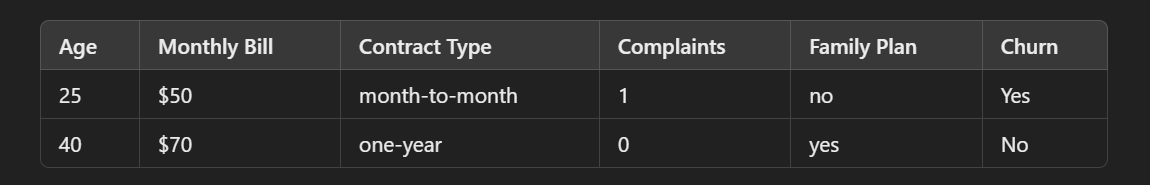

In [1]:
pip install catboost

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 MB 8.0 MB/s eta 0:00:00


In [9]:
## 01. import CatBoostClassifier and Pool from catboost library
from catboost import CatBoostClassifier, Pool

# CatBoosClassifier: For creating and training the classification model.
# Pool: For specifying which features are categorical.




## 02. import train_test_split from sklearn.model_selection
from sklearn.model_selection import train_test_split

# model_selection is a module




## 03. import accuracy_score function from sklearn.metrics module
from sklearn.metrics import accuracy_score



## 04. Example Data Introduction
data = [
    [25, 50, 'month-to-month', 1, 'no'],
    [40, 70, 'one-year', 0, 'yes'],
    [30, 60, 'month-to-month', 1, 'yes'],
    [35, 80, 'two-year', 0, 'no']
]
labels = [1, 0, 1, 0]  # 1 means churn, 0 means not churn






## 05. Introducing X_Train, X_test, y_train and y_test
X_train, X_test, y_train, y_test = train_test_split(data,labels,test_size=0.2,random_state=42)



## 06. Identify Categorical Features
categorical_features = [2,4]



## 07. Create pool objects for training and testing data
train_pool = Pool(data=X_train,label=y_train,cat_features=categorical_features)
test_pool = Pool(data=X_test,label=y_test,cat_features=categorical_features)




## 08. Initialize CatBoostClassifier
model = CatBoostClassifier(iterations=100,learning_rate=0.1,depth=5,verbose=False)



## 09. Train the CLassifier.
model.fit(train_pool)




## 10. Make Predictions
y_pred = model.predict(test_pool)


## 11. Checking Accuracy
accuracy = accuracy_score(y_test,y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.0


##02. Real Project

###02.01. Import Libraries

In [11]:
### 01. Import Libraries

import numpy as np
import pandas as pd
import os  # The OS Library in Python helps you to interact with Operating System.
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (classification_report,recall_score,confusion_matrix,roc_auc_score,
                             precision_score,f1_score,roc_curve,auc)
from sklearn.preprocessing import OrdinalEncoder

###02.02. Data Loading and Pre-Processing

In [15]:
### 02. Customer Churn Data Upload

from google.colab import drive
drive.mount('/content/drive')


data_path = '/content/drive/MyDrive/Machine Learning Projects/Telco-Customer-Churn.csv'
df = pd.read_csv(data_path)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
